In [1]:
import bldw
import numpy as np
import blimpy as bl
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
import setigen as stg
import multiprocessing
import logging
from astropy import units as u
%matplotlib inline

plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

numexpr.utils   INFO     Note: NumExpr detected 40 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
numexpr.utils   INFO     NumExpr defaulting to 8 threads.


In [9]:
outdir = '/datax/scratch/benjb/bl_nearby_stars/test_060226/'

logger = logging.getLogger(__name__)

df = pd.read_csv('/datax/scratch/benjb/bl_nearby_stars/BL_NSS_cadences_turboSETI_BLISS_062626b.csv')

In [3]:
logs = np.sort(glob.glob(outdir+'*.log'))
for i in logs:
    print(i)

/datax/scratch/benjb/bl_nearby_stars/test_060226/0_0_0_0_060226.log
/datax/scratch/benjb/bl_nearby_stars/test_060226/0_0_0_1_060226.log
/datax/scratch/benjb/bl_nearby_stars/test_060226/0_0_0_2_060226.log
/datax/scratch/benjb/bl_nearby_stars/test_060226/0_0_0_3_060226.log
/datax/scratch/benjb/bl_nearby_stars/test_060226/0_0_0_4_061626.log
/datax/scratch/benjb/bl_nearby_stars/test_060226/0_0_0_5_061626.log


In [6]:
log = logs[5]
with open(log, mode='r') as f:
    lines = f.readlines()
    print(len(lines))

34624


In [7]:
print(lines[-1])

INFO:__main__:34623 of 34624: Already searched.



In [8]:
print(len(df[~df['bliss .dat path 1'].isnull()].index.tolist()))

34633


In [11]:
bdat1 = df['bliss .dat path 1'].values
bdat2 = df['bliss .dat path 2'].values
bdat3 = df['bliss .dat path 3'].values
bdat4 = df['bliss .dat path 4'].values
bdat5 = df['bliss .dat path 5'].values
bdat6 = df['bliss .dat path 6'].values

In [14]:
for i, bdat in enumerate(bdat1):
    if i%100 == 0:
        print(i)
    if str(bdat)=='nan':
        continue
    with open(bdat, mode='r') as f:
        ll = f.readlines()
        if len(ll) == 0:
            print(df['.h5 path 1'].values[i])

0
100
/datag/pipeline/AGBT23A_999_37/blc01_blp01/blc01_guppi_60223_03425_GJ15A_0010.rawspec.0000.h5
/datag/pipeline/AGBT23A_999_37/blc05_blp05/blc05_guppi_60223_03425_GJ15A_0010.rawspec.0000.h5
/datag/pipeline/AGBT23A_999_37/blc06_blp06/blc06_guppi_60223_03425_GJ15A_0010.rawspec.0000.h5
200
/datag/pipeline/AGBT23A_999_42/blc46_blp06/blc46_guppi_60231_41210_GJ166_0022.rawspec.0000.h5
/datag/pipeline/AGBT23A_999_43/blc46_blp06/blc46_guppi_60233_40349_GJ166BC_0022.rawspec.0000.h5
/datag/pipeline/AGBT23A_999_38/blc01_blp01/blc01_guppi_60224_50695_GJ234_0046.rawspec.0000.h5
300
/datag/pipeline/AGBT23A_999_38/blc05_blp05/blc05_guppi_60224_50695_GJ234_0046.rawspec.0000.h5
/datag/pipeline/AGBT23A_999_38/blc06_blp06/blc06_guppi_60224_50695_GJ234_0046.rawspec.0000.h5
400
500
600
/datag/pipeline/AGBT19A_999_67/blc70/blc70_guppi_58684_86136_GJ412A_0034.gpuspec.0000.h5
700
800
900
1000
1100
1200
/datag/pipeline/AGBT23A_999_37/blc01_blp01/blc01_guppi_60223_21259_GJ820A_0064.rawspec.0000.h5
/datag/pi

KeyboardInterrupt: 

In [27]:
fb = bl.Waterfall('/datag/pipeline/AGBT18B_999_85/blc43/blc43_guppi_58475_05549_HIP112935_0026.gpuspec.0000.h5', 
                    load_data=False)
fb.info()


--- File Info ---
DIMENSION_LABELS : [b'time' b'feed_id' b'frequency']
        az_start :                              0.0
       data_type :                                1
            fch1 :           10688.964842353016 MHz
            foff :      -2.7939677238464355e-06 MHz
           ibeam :                                1
      machine_id :                               20
          nbeams :                                1
           nbits :                               32
          nchans :                         67108864
            nifs :                                1
     rawdatafile : guppi_58475_05549_HIP112935_0026.0000.raw
     source_name :                        HIP112935
         src_dej :                      9:50:08.022
         src_raj :                     22:52:24.582
    telescope_id :                                6
           tsamp :                     18.253611008
   tstart (ISOT) :          2018-12-23T01:32:29.000
    tstart (MJD) :                5

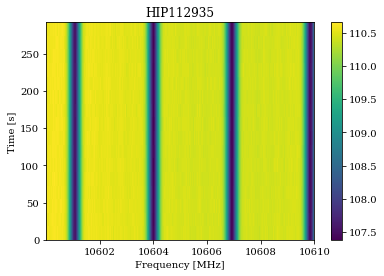

In [28]:
fb = bl.Waterfall('/datag/pipeline/AGBT18B_999_85/blc43/blc43_guppi_58475_05549_HIP112935_0026.gpuspec.0000.h5', 
                    f_start=10600, f_stop=10610
                    )
fb.plot_waterfall()

In [ ]:
snr = 20
l1 = 30

def process_files(i):
    logger.info('Started.')
    print(i, 'started')
    dfi = df[~df[f'bliss .dat path {i+5}'].isnull()]
    h5_list = dfi[f'.h5 path {i+5}'].values
    dat_list = dfi[f'bliss .dat path {i+5}'].values
    nfiles = len(dat_list)

    # Remove all handlers associated with the root logger object.
    print('Configuring logger')
    for handler in logging.root.handlers[:]:
        logging.root.removeHandler(handler)
    logging.basicConfig(filename=f'{outdir}0_0_0_{i+4}_061626.log', filemode='a', level=logging.DEBUG)
    for j, file in enumerate(h5_list):
        dat = dat_list[j]
        if os.path.getsize(dat) == 0:
            logger.info(f'{j} of {nfiles}: Empty! Re-searching ...')
            for k in range(64):
                console = f'bliss_find_hits {file} -e /datax/scratch/benjb/bl_nearby_stars/GBT_spliced_PFB_response.f32 --number-coarse 1 -c {k} --nchan-per-coarse 1048576 -d cuda:{i} -md -4 -MD 4 -s 20 --distance 30 --output ' + outdir + f'{j}_{i+5}_{k}_' + os.path.basename(file)[:-3] + f'_nosig_nosk_SNR_20_L1_30.dat'
                os.system(console)
        else:
            logger.info(f'{j} of {nfiles}: Already searched.')

if __name__ == "__main__":
    # Create a pool of n processes
    print('Attempting pool map ...')
    with multiprocessing.Pool(processes=4) as pool:
        # Map the process_files function to each file set
        pool.map(process_files, [0,1])

In [29]:
print(outdir)

/datax/scratch/benjb/bl_nearby_stars/test_060226/


In [30]:
dats = glob.glob(outdir+'*.dat')

In [31]:
print(len(dats))

1454528


In [32]:
print(dats[0])

/datax/scratch/benjb/bl_nearby_stars/test_060226/30_4_0_blc41_guppi_60358_84814_HIP897_0050.rawspec.0000_nosig_nosk_SNR_20_L1_30.dat


In [38]:
for i in range(1000):
    with open(dats[i], mode='r') as f:
        nhits = len(f.readlines())-9
        if nhits > 0:
            print(i, nhits)

1 3
2 13
3 2
4 1
7 1
9 3
11 352
15 3
17 4
18 1
22 19
23 66
25 54
26 75
28 5
29 1
31 127
33 41
34 2
35 49
36 1
40 1
48 382
50 194
58 1
63 5
65 842
67 3
68 44
69 3
70 2
71 1
72 5
73 2
74 2
75 2
76 1
77 5
78 3
79 4
81 12
82 3
84 3
86 1
87 2
89 1
91 11
93 2
94 1
96 6
97 1
99 5
101 3
103 1
109 1
112 1
114 3
116 2
136 3
139 698
141 3
145 1
154 118
156 314
158 4
163 89
164 1
168 926
170 1
174 3
175 48
177 4
178 5
180 4
185 4
186 2
187 2
191 1
192 6
194 1
195 3
199 1
204 1
205 1
210 2
217 2
220 20
221 473
222 1
223 67
224 1
225 3
226 3
227 1
229 1
230 18
233 22
237 2
239 562
240 52
242 1
243 877
244 1
245 35
246 11
248 7
252 2
257 2
258 18
259 2
260 9
263 9
264 2
265 618
270 23
272 4
279 49
281 29
285 4
287 450
289 4
293 1
296 4
297 7
298 123
300 51
301 9
304 55
305 15
307 7
308 48
312 21
313 1089
314 3
317 1
318 1
321 18
325 16
326 4
328 162
329 1
333 269
336 12
337 5
338 3
339 38
340 17
341 102
342 7
343 1
346 86
347 1
349 1
352 264
353 17
356 16
358 1
359 37
362 2
367 953
369 31
370 748
371